# Part 2: EDA Visualization

## 0. Setup

In [1]:
# ── Imports ──────────────────────────────────────────────────
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import seaborn as sns
import squarify
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)


In [2]:
# ── Data Loading ─────────────────────────────────────────────
products   = pd.read_csv("data/products.csv", parse_dates=["snapshot_date"] if False else None)
order_items = pd.read_csv("data/order_items.csv")
orders     = pd.read_csv("data/orders.csv",    parse_dates=["order_date"])
returns    = pd.read_csv("data/returns.csv")
payments   = pd.read_csv("data/payments.csv")
shipments  = pd.read_csv("data/shipments.csv", parse_dates=["ship_date", "delivery_date"])
inventory  = pd.read_csv("data/inventory.csv", parse_dates=["snapshot_date"])
sales      = pd.read_csv("data/sales.csv",     parse_dates=["Date"])


/var/folders/jq/3spgz0t105z044g721j_zwdw0000gn/T/ipykernel_19618/2656080263.py:3: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("data/order_items.csv")


In [3]:
# ── Shared Constants ─────────────────────────────────────────
SEGMENT_TO_CATEGORY = {
    "Activewear":  "Outdoor",
    "Premium":     "Outdoor",
    "Balanced":    "Streetwear",
    "Everyday":    "Streetwear",
    "Performance": "Streetwear",
    "Standard":    "Streetwear",
    "All-weather": "Casual",
    "Trendy":      "GenZ",
}

CATEGORY_PALETTE = {
    "Casual":     "#66c2a5",
    "GenZ":       "#fc8d62",
    "Outdoor":    "#8da0cb",
    "Streetwear": "#e78ac3",
}

RFM_COLORS = {
    "Champion":           "#1A535C",
    "Loyal Customers":    "#266D77",
    "Potential Loyalists":"#4ECDC4",
    "Promising":          "#7FBBA1",
    "New Customer":       "#A8DADC",
    "Need Attention":     "#F4A261",
    "About to Sleep":     "#E76F51",
    "At Risk":            "#F08080",
    "Can't Lose Them":    "#C72B4C",
    "Hibernating":        "#BC6C74",
}


---
## 1. Revenue & Profitability

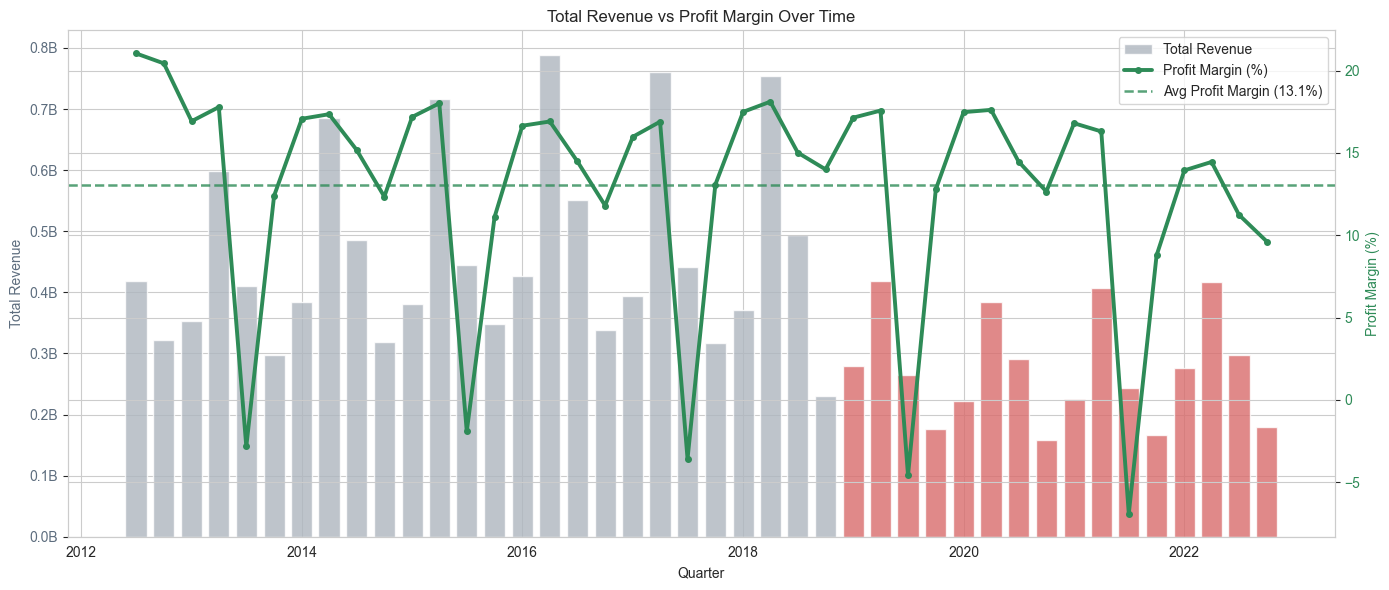

In [4]:
# ── Quarterly Revenue vs Profit Margin ───────────────────────
quarterly_pm = (
    sales.assign(quarter=sales["Date"].dt.to_period("Q").dt.to_timestamp())
    .groupby("quarter", as_index=False)
    .agg(total_revenue=("Revenue", "sum"), total_cogs=("COGS", "sum"))
)
quarterly_pm["profit"] = quarterly_pm["total_revenue"] - quarterly_pm["total_cogs"]
quarterly_pm["profit_margin_pct"] = quarterly_pm["profit"] / quarterly_pm["total_revenue"] * 100
quarterly_pm["bar_color"] = np.where(
    quarterly_pm["quarter"] < pd.Timestamp("2019-01-01"), "#AEB6BF", "#D96C6C"
)

def billions(x, pos): return f"{x/1e9:.1f}B"

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(quarterly_pm["quarter"], quarterly_pm["total_revenue"],
        color=quarterly_pm["bar_color"], alpha=0.8, width=70, label="Total Revenue")
ax1.set_title("Total Revenue vs Profit Margin Over Time")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Total Revenue", color="#5D6D7E")
ax1.tick_params(axis="y", labelcolor="#5D6D7E")
ax1.yaxis.set_major_formatter(FuncFormatter(billions))

ax2 = ax1.twinx()
avg_margin = quarterly_pm["profit_margin_pct"].mean()
ax2.plot(quarterly_pm["quarter"], quarterly_pm["profit_margin_pct"],
         color="#2E8B57", linewidth=2.8, marker="o", markersize=4, label="Profit Margin (%)")
ax2.axhline(avg_margin, color="#2E8B57", linestyle="--", linewidth=1.8, alpha=0.8,
            label=f"Avg Profit Margin ({avg_margin:.1f}%)")
ax2.set_ylabel("Profit Margin (%)", color="#2E8B57")
ax2.tick_params(axis="y", labelcolor="#2E8B57")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True)
plt.tight_layout()
plt.savefig("data/output/revenue_profit_margin.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 2. Inventory Health

### 2.1 Feature Engineering for Inventory

- **Overstock**: more stock than demand
- **Stockout**: too little stock to meet demand


In [5]:
# ── Merge products info into inventory ───────────────────────
products_slim = products[["product_id", "cogs", "category", "segment"]]
inventory = inventory.merge(products_slim, on="product_id", how="left",
                            suffixes=("", "_prod"))
inventory["category_final"] = inventory["category"].fillna(inventory["category_prod"])
inventory["segment_final"]  = inventory["segment"].fillna(inventory["segment_prod"])
inventory["inventory_value"] = inventory["stock_on_hand"] * inventory["cogs"]
inventory["sold_value"]      = inventory["units_sold"]    * inventory["cogs"]

inventory["year"]   = inventory["snapshot_date"].dt.year
inventory["half"]   = np.where(inventory["snapshot_date"].dt.month <= 6, "H1", "H2")
inventory["period"] = inventory["year"].astype(str) + "-" + inventory["half"]
inventory["era"]    = np.where(inventory["year"] < 2019, "2012-2018", "2019-2022")

inventory.head(3)


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,...,cogs,category_prod,segment_prod,category_final,segment_final,inventory_value,sold_value,half,period,era
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,...,2732.8833,Casual,All-weather,Casual,All-weather,8198.6499,2732.8833,H2,2022-H2,2019-2022
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,...,2732.8833,Casual,All-weather,Casual,All-weather,8198.6499,2732.8833,H2,2022-H2,2019-2022
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,...,2732.8833,Casual,All-weather,Casual,All-weather,8198.6499,2732.8833,H2,2022-H2,2019-2022


### 2.2 Stockout vs Overstock by Category

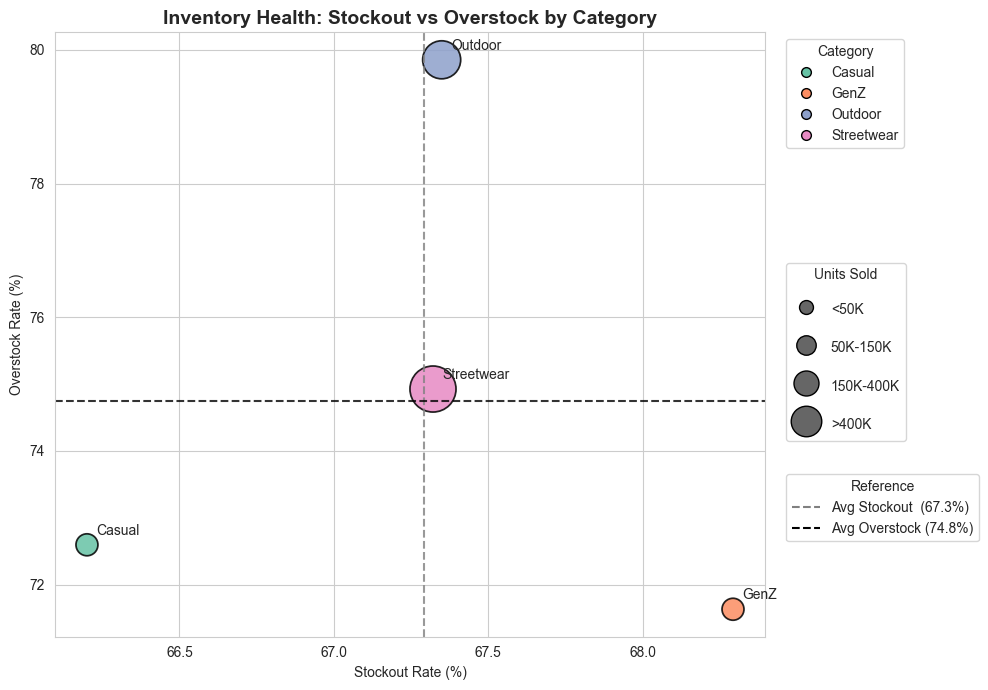

In [6]:
# ── Aggregate by category ────────────────────────────────────
category_inventory = (
    inventory.groupby("category", as_index=False)
    .agg(stockout_rate=("stockout_flag", "mean"),
         overstock_rate=("overstock_flag", "mean"),
         total_units_sold=("units_sold", "sum"))
)
category_inventory["stockout_rate_pct"]  = category_inventory["stockout_rate"]  * 100
category_inventory["overstock_rate_pct"] = category_inventory["overstock_rate"] * 100

bins   = [0, 50000, 150000, 400000, float("inf")]
labels = ["<50K", "50K-150K", "150K-400K", ">400K"]
category_inventory["volume_group"] = pd.cut(
    category_inventory["total_units_sold"], bins=bins, labels=labels, include_lowest=True
)
size_map   = {"<50K": 250, "50K-150K": 450, "150K-400K": 750, ">400K": 1100}
ms_map_cat = {"<50K": 10,  "50K-150K": 14,  "150K-400K": 18,  ">400K": 22}

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=category_inventory, x="stockout_rate_pct", y="overstock_rate_pct",
                hue="category", size="volume_group", sizes=size_map,
                palette=CATEGORY_PALETTE, alpha=0.85, edgecolor="black", legend=False, ax=ax)

for _, row in category_inventory.iterrows():
    ax.text(row["stockout_rate_pct"] + 0.03, row["overstock_rate_pct"] + 0.15,
            row["category"], fontsize=10)

avg_so = category_inventory["stockout_rate_pct"].mean()
avg_os = category_inventory["overstock_rate_pct"].mean()
ax.axvline(avg_so, linestyle="--", color="gray",  alpha=0.8)
ax.axhline(avg_os, linestyle="--", color="black", alpha=0.8)

ax.set_title("Inventory Health: Stockout vs Overstock by Category", fontsize=14, weight="bold")
ax.set_xlabel("Stockout Rate (%)")
ax.set_ylabel("Overstock Rate (%)")

# Legend: category colours
legend1 = ax.legend(
    handles=[Line2D([0],[0], marker="o", color="w", label=cat,
                    markerfacecolor=col, markeredgecolor="black", markersize=7)
             for cat, col in CATEGORY_PALETTE.items()],
    title="Category", loc="upper left", bbox_to_anchor=(1.02, 1.00), frameon=True)
ax.add_artist(legend1)

# Legend: bubble sizes
legend2 = ax.legend(
    handles=[Line2D([0],[0], marker="o", color="w", label=lbl,
                    markerfacecolor="#666", markeredgecolor="black", markersize=ms)
             for lbl, ms in ms_map_cat.items()],
    title="Units Sold", loc="upper left", bbox_to_anchor=(1.02, 0.63),
    frameon=True, labelspacing=1.2, handleheight=2.0)
ax.add_artist(legend2)

# Legend: reference lines
ax.legend(
    handles=[Line2D([0],[0], color="gray",  linestyle="--", label=f"Avg Stockout  ({avg_so:.1f}%)"),
             Line2D([0],[0], color="black", linestyle="--", label=f"Avg Overstock ({avg_os:.1f}%)")],
    title="Reference", loc="upper left", bbox_to_anchor=(1.02, 0.28), frameon=True)

plt.tight_layout()
plt.show()


**Insights:**
- `Outdoor` has the highest overstock rate while stockout rate is still above average — holding too much stock but distributed poorly.
- `GenZ` has the highest stockout rate but lowest overstock rate → risk of lost sales from thin inventory.
- `Casual` is healthiest: both rates below average.


### 2.3 Stockout vs Overstock by Segment

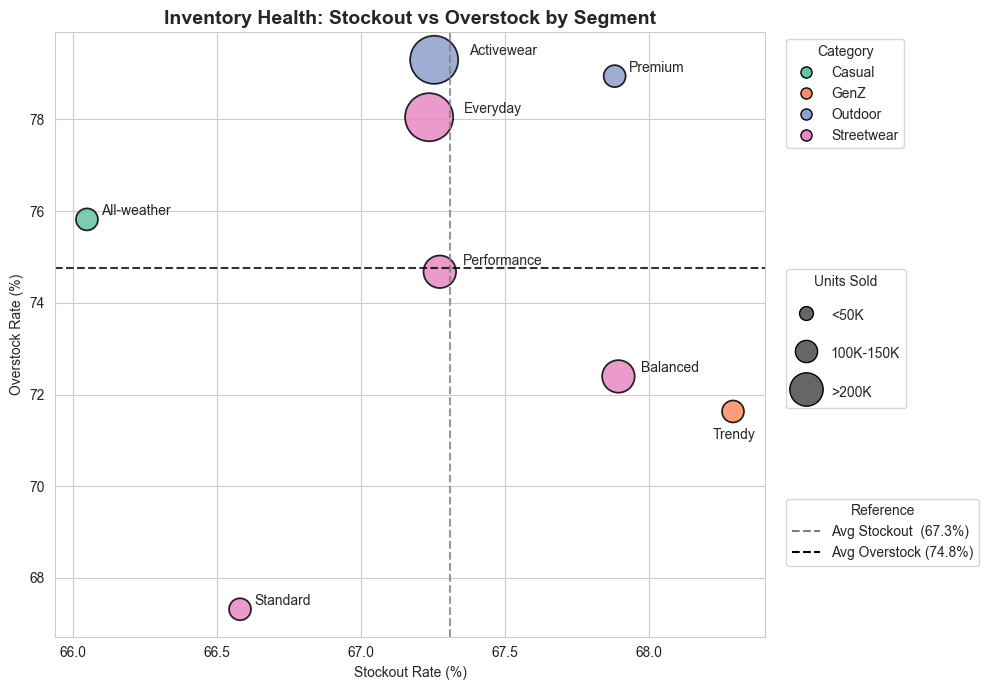

In [7]:
# ── Aggregate by segment ─────────────────────────────────────
segment_inventory = (
    inventory.groupby("segment", as_index=False)
    .agg(stockout_rate=("stockout_flag", "mean"),
         overstock_rate=("overstock_flag", "mean"),
         total_units_sold=("units_sold", "sum"))
)
segment_inventory["stockout_rate_pct"]  = segment_inventory["stockout_rate"]  * 100
segment_inventory["overstock_rate_pct"] = segment_inventory["overstock_rate"] * 100
segment_inventory["category"] = segment_inventory["segment"].map(SEGMENT_TO_CATEGORY)

# 3 volume tiers
segment_inventory["volume_group"] = np.select(
    [segment_inventory["total_units_sold"] < 50000,
     segment_inventory["total_units_sold"].between(100000, 150000),
     segment_inventory["total_units_sold"] > 200000],
    ["<50K", "100K-150K", ">200K"], default="Other"
)
plot_data = segment_inventory[segment_inventory["volume_group"] != "Other"].copy()
size_map_seg = {"<50K": 250, "100K-150K": 550, ">200K": 1200}
ms_map_seg   = {"<50K": 10,  "100K-150K": 16,  ">200K": 24}

label_offsets = {
    "Activewear": (0.12, 0.10), "Everyday":    (0.12, 0.10),
    "Performance":(0.08, 0.15), "Premium":     (0.05, 0.10),
    "Balanced":   (0.08, 0.10), "Trendy":      (-0.07, -0.6),
    "All-weather":(0.05, 0.10), "Standard":    (0.05, 0.10),
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=plot_data, x="stockout_rate_pct", y="overstock_rate_pct",
                hue="category", size="volume_group", sizes=size_map_seg,
                palette=CATEGORY_PALETTE, alpha=0.85, edgecolor="black", legend=False, ax=ax)

for _, row in plot_data.iterrows():
    dx, dy = label_offsets.get(row["segment"], (0.03, 0.10))
    ax.text(row["stockout_rate_pct"] + dx, row["overstock_rate_pct"] + dy,
            row["segment"], fontsize=10)

avg_so_s = plot_data["stockout_rate_pct"].mean()
avg_os_s = plot_data["overstock_rate_pct"].mean()
ax.axvline(avg_so_s, linestyle="--", color="gray",  alpha=0.8)
ax.axhline(avg_os_s, linestyle="--", color="black", alpha=0.8)

ax.set_title("Inventory Health: Stockout vs Overstock by Segment", fontsize=14, weight="bold")
ax.set_xlabel("Stockout Rate (%)")
ax.set_ylabel("Overstock Rate (%)")

legend1 = ax.legend(
    handles=[Line2D([0],[0], marker="o", color="w", label=cat,
                    markerfacecolor=col, markeredgecolor="black", markersize=8)
             for cat, col in CATEGORY_PALETTE.items()],
    title="Category", loc="upper left", bbox_to_anchor=(1.02, 1.00), frameon=True)
ax.add_artist(legend1)

legend2 = ax.legend(
    handles=[Line2D([0],[0], marker="o", color="w", label=lbl,
                    markerfacecolor="#666", markeredgecolor="black", markersize=ms)
             for lbl, ms in ms_map_seg.items()],
    title="Units Sold", loc="upper left", bbox_to_anchor=(1.02, 0.62),
    frameon=True, labelspacing=1.2, handleheight=2.0)
ax.add_artist(legend2)

ax.legend(
    handles=[Line2D([0],[0], color="gray",  linestyle="--", label=f"Avg Stockout  ({avg_so_s:.1f}%)"),
             Line2D([0],[0], color="black", linestyle="--", label=f"Avg Overstock ({avg_os_s:.1f}%)")],
    title="Reference", loc="upper left", bbox_to_anchor=(1.02, 0.24), frameon=True)

plt.tight_layout()
plt.savefig("data/output/stockout_overstock_segment.png", dpi=150, bbox_inches="tight")
plt.show()


**Insights:**
- `Activewear` & `Premium`: high both rates — holding too much but service level is still poor.
- `Balanced` & `Trendy`: overstock below average but stockout high → risk of lost sales.
- `Standard` is healthiest: both rates below average.


### 2.4 Inventory Turnover & DIO

In [8]:
# ── Build period-level turnover table (reused by CCC later) ──
monthly_inv_total = (
    inventory.groupby("snapshot_date", as_index=False)["inventory_value"]
    .sum().rename(columns={"inventory_value": "total_inventory_value"})
)
monthly_inv_total["period"] = (
    monthly_inv_total["snapshot_date"].dt.year.astype(str) + "-" +
    np.where(monthly_inv_total["snapshot_date"].dt.month <= 6, "H1", "H2")
)

period_inventory = (
    monthly_inv_total.groupby("period", as_index=False)["total_inventory_value"]
    .mean().rename(columns={"total_inventory_value": "avg_inventory_value"})
)
period_sales = inventory.groupby("period", as_index=False)["sold_value"].sum()

period_turnover = period_inventory.merge(period_sales, on="period", how="left")
period_turnover["inventory_turnover"] = (
    period_turnover["sold_value"] / period_turnover["avg_inventory_value"]
)
period_turnover["dio"]  = (
    period_turnover["avg_inventory_value"] / period_turnover["sold_value"] * 182.5
)
period_turnover["year"] = period_turnover["period"].str[:4].astype(int)
period_turnover["era"]  = np.where(period_turnover["year"] < 2019, "2012-2018", "2019-2022")
period_turnover["bar_color"] = np.where(period_turnover["year"] < 2019, "#CFCFCF", "#D95F5F")


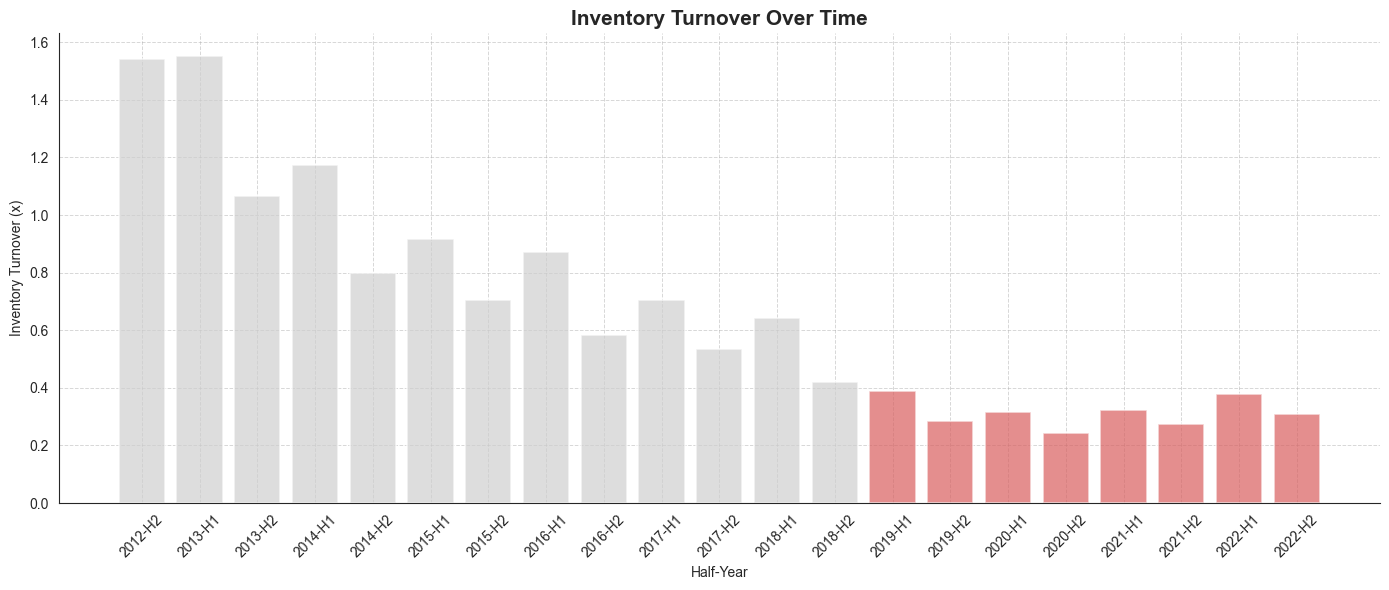

,inventory_turnover,dio
era,,
2012-2018,0.89,237.61
2019-2022,0.31,592.89


In [9]:
# ── Plot: Inventory Turnover over time ───────────────────────
sns.set_style("white")
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(period_turnover["period"], period_turnover["inventory_turnover"],
       color=period_turnover["bar_color"], edgecolor="white", linewidth=1.2, alpha=0.7)
ax.set_title("Inventory Turnover Over Time", fontsize=15, weight="bold")
ax.set_xlabel("Half-Year"); ax.set_ylabel("Inventory Turnover (x)")
ax.tick_params(axis="x", rotation=45)
ax.set_axisbelow(True)
ax.grid(True, axis="both", linestyle="--", linewidth=0.7, alpha=0.5, color="#B0B0B0")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("data/output/inventory_turnover.png", dpi=150, bbox_inches="tight")
plt.show()

period_turnover.groupby("era")[["inventory_turnover","dio"]].mean().round(2)


**Insights:**
- Inventory Turnover dropped from `0.89` → `0.31` (↓ ~65%) — stock rotates far slower.
- DIO rose from `238` → `593` days (↑ ~150%) — products sit in warehouse much longer before selling.


### 2.5 Inventory Turnover Change by Category & Segment

/var/folders/jq/3spgz0t105z044g721j_zwdw0000gn/T/ipykernel_19618/418596.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_change, y="category_final", x="decline_pct", palette="Blues_r", ax=axes[0])
/var/folders/jq/3spgz0t105z044g721j_zwdw0000gn/T/ipykernel_19618/418596.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_change, y="segment_final", x="decline_pct", palette="Oranges_r", ax=axes[1])


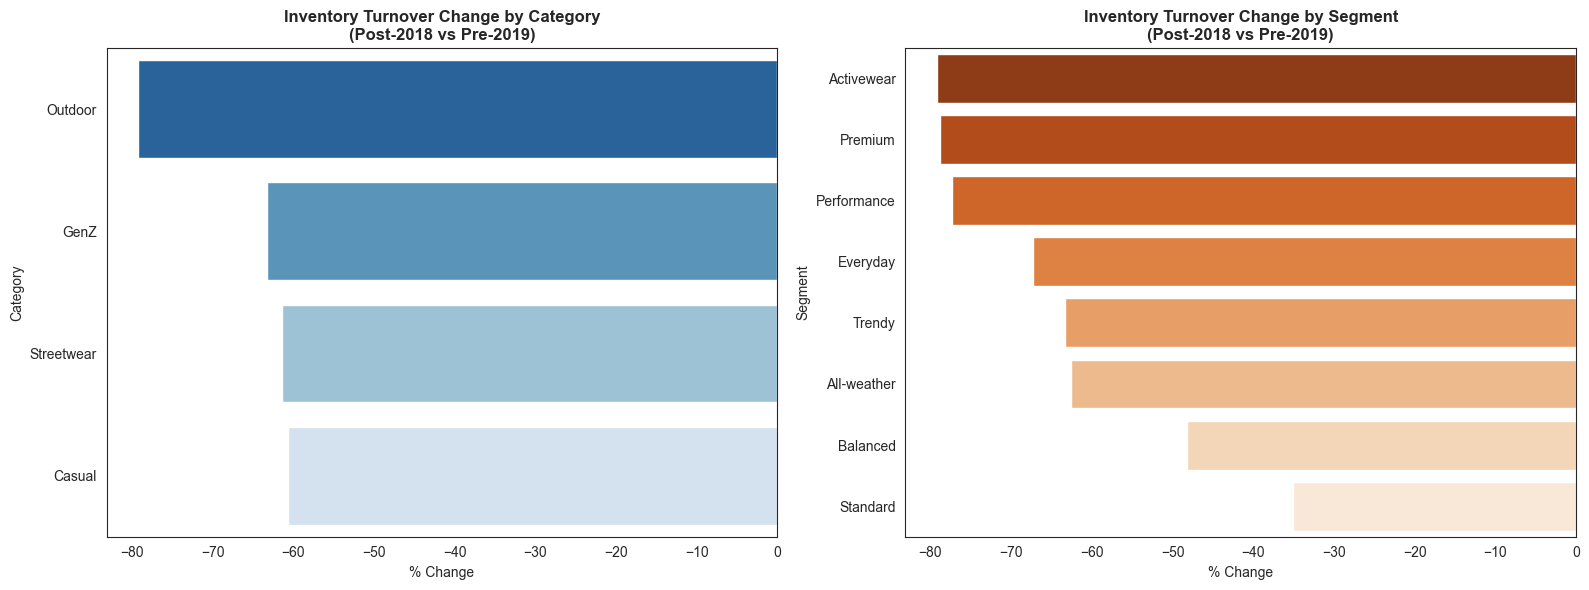

category_final  2012-2018  2019-2022  decline_pct
       Outdoor   0.880865   0.183315   -79.189244
          GenZ   0.886654   0.325412   -63.298838
    Streetwear   0.887246   0.341973   -61.456740
        Casual   1.044723   0.411455   -60.615865


In [10]:
def turnover_change(df, group_col):
    """Compute inventory turnover % change pre/post 2019 for a given grouping."""
    monthly = (
        df.groupby([group_col, "snapshot_date"], as_index=False)["inventory_value"]
        .sum().rename(columns={"inventory_value": "total_inventory_value"})
    )
    monthly["period"] = (
        monthly["snapshot_date"].dt.year.astype(str) + "-" +
        np.where(monthly["snapshot_date"].dt.month <= 6, "H1", "H2")
    )
    inv_agg = (
        monthly.groupby([group_col, "period"], as_index=False)["total_inventory_value"]
        .mean().rename(columns={"total_inventory_value": "avg_inventory_value"})
    )
    sales_agg = df.groupby([group_col, "period"], as_index=False)["sold_value"].sum()
    t = inv_agg.merge(sales_agg, on=[group_col, "period"], how="left")
    t["inventory_turnover"] = t["sold_value"] / t["avg_inventory_value"]
    t["year"] = t["period"].str[:4].astype(int)
    t["era"]  = np.where(t["year"] < 2019, "2012-2018", "2019-2022")

    change = (
        t.groupby([group_col, "era"], as_index=False)["inventory_turnover"].mean()
        .pivot(index=group_col, columns="era", values="inventory_turnover")
        .reset_index()
    )
    change["decline_pct"] = (change["2019-2022"] - change["2012-2018"]) / change["2012-2018"] * 100
    return change.sort_values("decline_pct")

category_change = turnover_change(inventory, "category_final")
segment_change  = turnover_change(inventory, "segment_final")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=category_change, y="category_final", x="decline_pct", palette="Blues_r", ax=axes[0])
axes[0].set_title("Inventory Turnover Change by Category\n(Post-2018 vs Pre-2019)", weight="bold")
axes[0].set_xlabel("% Change"); axes[0].set_ylabel("Category")

sns.barplot(data=segment_change, y="segment_final", x="decline_pct", palette="Oranges_r", ax=axes[1])
axes[1].set_title("Inventory Turnover Change by Segment\n(Post-2018 vs Pre-2019)", weight="bold")
axes[1].set_xlabel("% Change"); axes[1].set_ylabel("Segment")

plt.tight_layout()
plt.show()

print(category_change[["category_final","2012-2018","2019-2022","decline_pct"]].to_string(index=False))


### 2.6 CCC Proxy (Cash Conversion Cycle)

In [11]:
# ── Build DSO proxy from orders + payments + shipments ───────
ccc = (
    orders[["order_id","order_date","payment_method"]]
    .merge(payments[["order_id","installments","payment_value"]], on="order_id", how="left")
    .merge(shipments[["order_id","delivery_date"]],              on="order_id", how="left")
)
ccc["cod_lag"] = (ccc["delivery_date"] - ccc["order_date"]).dt.days.clip(lower=0)
ccc["dso_proxy"] = np.select(
    [ccc["payment_method"].eq("cod"),
     ccc["payment_method"].eq("credit_card"),
     ccc["payment_method"].eq("paypal")],
    [ccc["cod_lag"].fillna(0),
     (ccc["installments"].fillna(1) - 1) * 15,
     0], default=0
)
ccc["period"] = (
    ccc["order_date"].dt.year.astype(str) + "-" +
    np.where(ccc["order_date"].dt.month <= 6, "H1", "H2")
)

dso_by_period = (
    ccc.groupby("period")
    .apply(lambda x: np.average(x["dso_proxy"], weights=x["payment_value"].fillna(0) + 1))
    .reset_index(name="dso_proxy")
)

ccc_proxy = period_turnover[["period","dio"]].merge(dso_by_period, on="period", how="left")
ccc_proxy["ccc_proxy"] = ccc_proxy["dio"] + ccc_proxy["dso_proxy"]
ccc_proxy["year"] = ccc_proxy["period"].str[:4].astype(int)
ccc_proxy["era"]  = np.where(ccc_proxy["year"] < 2019, "2012-2018", "2019-2022")


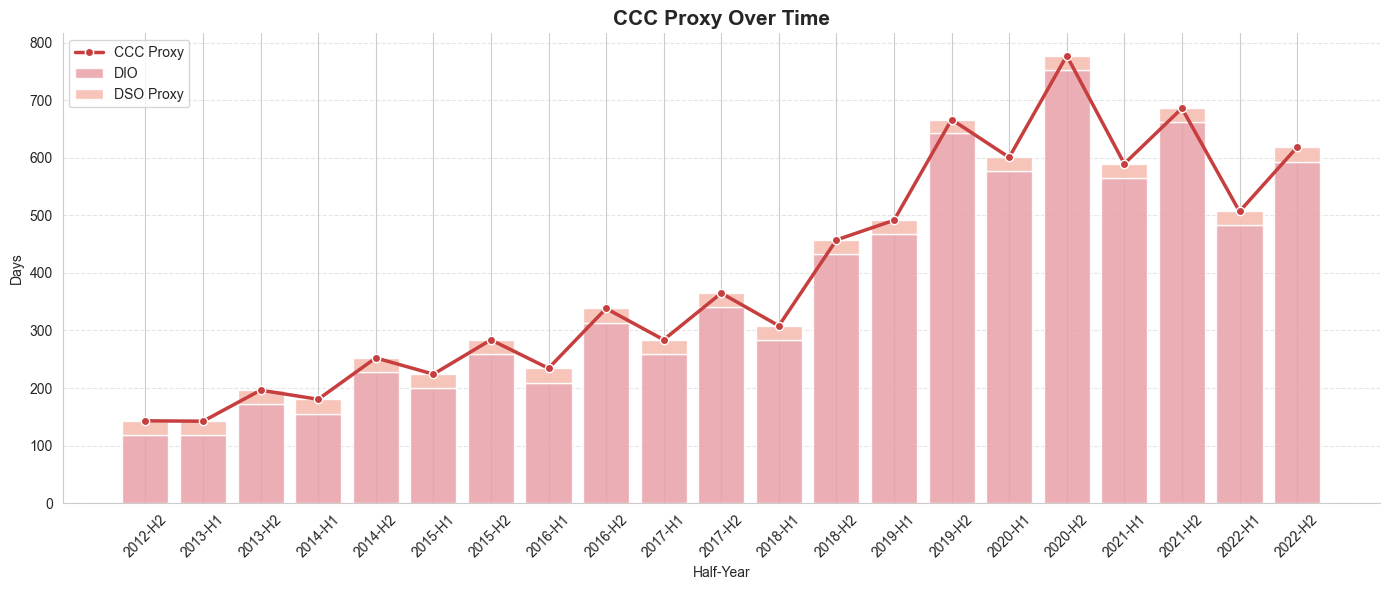

,dio,dso_proxy,ccc_proxy
era,,,
2012-2018,237.61,24.64,262.25
2019-2022,592.89,24.45,617.34


In [12]:
# ── Plot: CCC Proxy (stacked bar + line) ─────────────────────
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ccc_proxy))

ax.bar(x, ccc_proxy["dio"],       color="#E8A0A8", edgecolor="white", alpha=0.85, label="DIO")
ax.bar(x, ccc_proxy["dso_proxy"], bottom=ccc_proxy["dio"],
       color="#F6C1B6", edgecolor="white", alpha=0.95, label="DSO Proxy")
ax.plot(x, ccc_proxy["ccc_proxy"],
        color="#C73E3E", marker="o", linewidth=2.5, markersize=6,
        markerfacecolor="#C73E3E", markeredgecolor="white", label="CCC Proxy")

ax.set_title("CCC Proxy Over Time", fontsize=15, weight="bold")
ax.set_xlabel("Half-Year"); ax.set_ylabel("Days")
ax.set_xticks(x); ax.set_xticklabels(ccc_proxy["period"], rotation=45)
ax.grid(True, axis="y", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
ax.legend(frameon=True, loc="upper left")

plt.tight_layout()
plt.savefig("data/output/ccc_proxy.png", dpi=150, bbox_inches="tight")
plt.show()

ccc_proxy.groupby("era")[["dio","dso_proxy","ccc_proxy"]].mean().round(2)


**Insights:**
- CCC proxy rose from `262` → `617` days (+135%) — capital locked in inventory far longer.
- DSO proxy is nearly flat (~24 days) — collection efficiency unchanged.
- The deterioration is driven entirely by DIO, confirming inventory management as the root cause.


### 2.7 Sell-Through Rate

In [13]:
# ── Compute weighted STR ─────────────────────────────────────
sell_through = (
    inventory[inventory["units_received"] > 0]
    .groupby("period")
    .apply(lambda x: np.average(x["sell_through_rate"], weights=x["units_received"]))
    .reset_index(name="weighted_str")
)
sell_through["year"] = sell_through["period"].str[:4].astype(int)
sell_through["era"]  = np.where(sell_through["year"] < 2019, "2012-2018", "2019-2022")

segment_str = (
    inventory[inventory["units_received"] > 0]
    .groupby(["segment_final","period"])
    .apply(lambda x: np.average(x["sell_through_rate"], weights=x["units_received"]))
    .reset_index(name="weighted_str")
)
segment_str["year"] = segment_str["period"].str[:4].astype(int)
segment_str["era"]  = np.where(segment_str["year"] < 2019, "2012-2018", "2019-2022")
segment_str_change = (
    segment_str.groupby(["segment_final","era"], as_index=False)["weighted_str"].mean()
    .pivot(index="segment_final", columns="era", values="weighted_str").reset_index()
)
segment_str_change["change_pct"] = (
    (segment_str_change["2019-2022"] - segment_str_change["2012-2018"])
    / segment_str_change["2012-2018"] * 100
)
segment_str_change = segment_str_change.sort_values("change_pct")


/var/folders/jq/3spgz0t105z044g721j_zwdw0000gn/T/ipykernel_19618/2721309982.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_str_change, y="segment_final", x="change_pct",


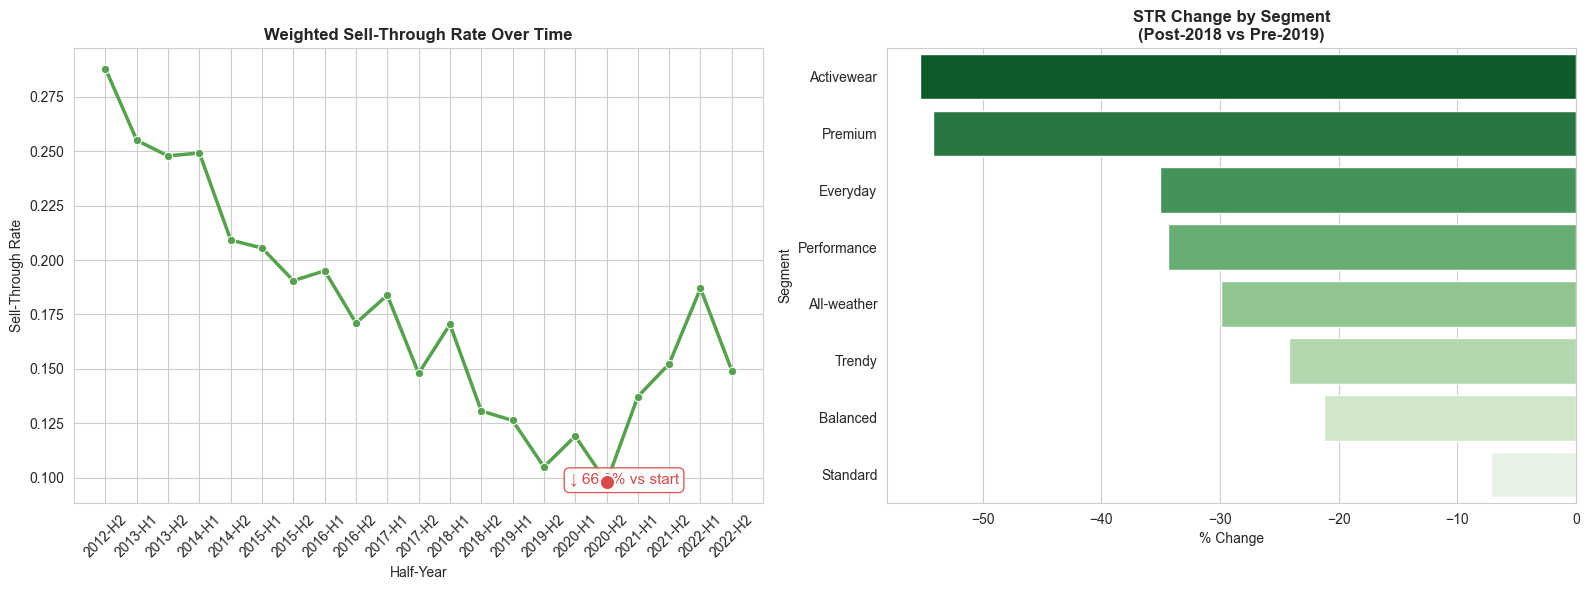

,weighted_str
era,
2012-2018,0.203
2019-2022,0.134


In [14]:
# ── Plot: STR over time + decline by segment ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: time-series
min_idx   = sell_through["weighted_str"].idxmin()
min_val   = sell_through.loc[min_idx, "weighted_str"]
start_val = sell_through.loc[0, "weighted_str"]
decline   = (min_val - start_val) / start_val * 100

sns.lineplot(data=sell_through, x="period", y="weighted_str",
             marker="o", linewidth=2.5, color="#54A24B", ax=axes[0])
axes[0].scatter(min_idx, min_val, s=120, color="#D94B4B", edgecolor="white", linewidth=1.5, zorder=5)
axes[0].text(min_idx + 2.3, min_val + 0.001,
             f"↓ {abs(decline):.1f}% vs start",
             ha="right", va="center", fontsize=11, color="#D94B4B",
             bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#D94B4B", alpha=0.9))
axes[0].set_title("Weighted Sell-Through Rate Over Time", weight="bold")
axes[0].set_xlabel("Half-Year"); axes[0].set_ylabel("Sell-Through Rate")
axes[0].tick_params(axis="x", rotation=45)

# Right: segment bar
sns.barplot(data=segment_str_change, y="segment_final", x="change_pct",
            palette="Greens_r", ax=axes[1])
axes[1].set_title("STR Change by Segment\n(Post-2018 vs Pre-2019)", weight="bold")
axes[1].set_xlabel("% Change"); axes[1].set_ylabel("Segment")

plt.tight_layout()
plt.savefig("data/output/sell_through_rate.png", dpi=150, bbox_inches="tight")
plt.show()

sell_through.groupby("era")["weighted_str"].mean().round(3).to_frame()


### 2.8 Interactive: Yearly Inventory Health by Segment

In [15]:
# ── Plotly animated dropdown ─────────────────────────────────
inventory_year = inventory.copy()
inventory_year["year"] = pd.to_datetime(inventory_year["snapshot_date"]).dt.year

segment_yearly = (
    inventory_year.groupby(["year","segment"], as_index=False)
    .agg(stockout_rate=("stockout_flag","mean"),
         overstock_rate=("overstock_flag","mean"),
         total_units_sold=("units_sold","sum"))
)
segment_yearly["stockout_rate_pct"]  = segment_yearly["stockout_rate"]  * 100
segment_yearly["overstock_rate_pct"] = segment_yearly["overstock_rate"] * 100
segment_yearly["category"] = segment_yearly["segment"].map(SEGMENT_TO_CATEGORY)
segment_yearly = segment_yearly.dropna(subset=["category"]).copy()
max_units = segment_yearly["total_units_sold"].max()
segment_yearly["bubble_size"] = 20 + 60 * np.sqrt(segment_yearly["total_units_sold"] / max_units)

years      = sorted(segment_yearly["year"].unique())
categories = list(CATEGORY_PALETTE.keys())
fig        = go.Figure()
trace_idx_by_year = {}
n_traces = 0

for year in years:
    trace_idx_by_year[year] = []
    df_y = segment_yearly[segment_yearly["year"] == year].copy()
    avg_so = df_y["stockout_rate_pct"].mean()
    avg_os = df_y["overstock_rate_pct"].mean()

    for cat in categories:
        d = df_y[df_y["category"] == cat].copy()
        cd = np.column_stack([d["segment"], d["category"], d["total_units_sold"]]) if len(d) else None
        fig.add_trace(go.Scatter(
            x=d["stockout_rate_pct"], y=d["overstock_rate_pct"],
            mode="markers+text", text=d["segment"], textposition="top center",
            name=cat, legendgroup=cat, showlegend=bool(year == years[0]),
            marker=dict(size=d["bubble_size"], color=CATEGORY_PALETTE[cat],
                        line=dict(color="black", width=1), opacity=0.85),
            customdata=cd,
            hovertemplate=(
                "<b>Segment:</b> %{customdata[0]}<br>"
                "<b>Category:</b> %{customdata[1]}<br>"
                "<b>Stockout Rate:</b> %{x:.2f}%<br>"
                "<b>Overstock Rate:</b> %{y:.2f}%<br>"
                "<b>Units Sold:</b> %{customdata[2]:,.0f}<extra></extra>"
            ) if len(d) else None,
            visible=bool(year == years[0])
        ))
        trace_idx_by_year[year].append(n_traces); n_traces += 1

    for line_x, line_y, is_v in [
        ([avg_so, avg_so], [df_y["overstock_rate_pct"].min()-1, df_y["overstock_rate_pct"].max()+1], True),
        ([df_y["stockout_rate_pct"].min()-0.2, df_y["stockout_rate_pct"].max()+0.2], [avg_os, avg_os], False),
    ]:
        fig.add_trace(go.Scatter(
            x=line_x, y=line_y, mode="lines",
            line=dict(color="gray" if is_v else "black", dash="dash"),
            showlegend=False, visible=bool(year == years[0])
        ))
        trace_idx_by_year[year].append(n_traces); n_traces += 1

buttons = []
for year in years:
    vis = [False] * n_traces
    for i in trace_idx_by_year[year]: vis[i] = True
    df_y   = segment_yearly[segment_yearly["year"] == year]
    avg_so = df_y["stockout_rate_pct"].mean()
    avg_os = df_y["overstock_rate_pct"].mean()
    buttons.append(dict(label=str(year), method="update",
        args=[{"visible": vis},
              {"title": f"Inventory Health by Segment ({year})"}]))

fig.update_layout(
    title=f"Inventory Health by Segment ({years[0]})",
    xaxis_title="Stockout Rate (%)", yaxis_title="Overstock Rate (%)",
    template="plotly_white", width=1100, height=700, legend_title="Category", font=dict(size=14),
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True,
                      x=1.02, xanchor="left", y=1.0, yanchor="top")],
    annotations=[dict(x=1.02, y=1.08, xref="paper", yref="paper",
                      text="Select Year", showarrow=False, font=dict(size=12))]
)
fig.update_xaxes(tickformat=".1f"); fig.update_yaxes(tickformat=".1f")
fig.show()


### 2.9 Summary Table

In [16]:
summary_table = pd.DataFrame({
    "Metric": ["Inventory Turnover", "DIO", "CCC Proxy", "Sell-Through Rate"],
    "2012-2018": [
        period_turnover.groupby("era")["inventory_turnover"].mean()["2012-2018"],
        period_turnover.groupby("era")["dio"].mean()["2012-2018"],
        ccc_proxy.groupby("era")["ccc_proxy"].mean()["2012-2018"],
        sell_through.groupby("era")["weighted_str"].mean()["2012-2018"],
    ],
    "2019-2022": [
        period_turnover.groupby("era")["inventory_turnover"].mean()["2019-2022"],
        period_turnover.groupby("era")["dio"].mean()["2019-2022"],
        ccc_proxy.groupby("era")["ccc_proxy"].mean()["2019-2022"],
        sell_through.groupby("era")["weighted_str"].mean()["2019-2022"],
    ],
})
summary_table["% Change"] = (
    (summary_table["2019-2022"] - summary_table["2012-2018"]) / summary_table["2012-2018"] * 100
)
summary_table.round(3)


,Metric,2012-2018,2019-2022,% Change
0,Inventory Turnover,0.885,0.315,-64.462
1,DIO,237.612,592.889,149.520
2,CCC Proxy,262.255,617.338,135.396
3,Sell-Through Rate,0.203,0.134,-34.021


---
## 3. Customer Analysis

### 3.1 Customer Volume Over Time

In [17]:
# ── Build order-level dataframe ──────────────────────────────
products["margin"] = (products["price"] - products["cogs"]) / products["price"]
df = order_items.merge(products, on="product_id", how="left")
df = df.merge(orders, on="order_id", how="left")
df["revenue"] = df["price"] * df.get("quantity", pd.Series(1, index=df.index))

returns["is_returned"] = 1
if "order_item_id" in returns.columns:
    df = df.merge(returns[["order_item_id","is_returned"]], on="order_item_id", how="left")
elif "order_id" in returns.columns and "product_id" in returns.columns:
    df = df.merge(returns[["order_id","product_id","is_returned"]], on=["order_id","product_id"], how="left")
elif "order_id" in returns.columns:
    df = df.merge(returns[["order_id","is_returned"]], on="order_id", how="left")
df["is_returned"] = df["is_returned"].fillna(0)
df["order_date"]  = pd.to_datetime(df["order_date"])


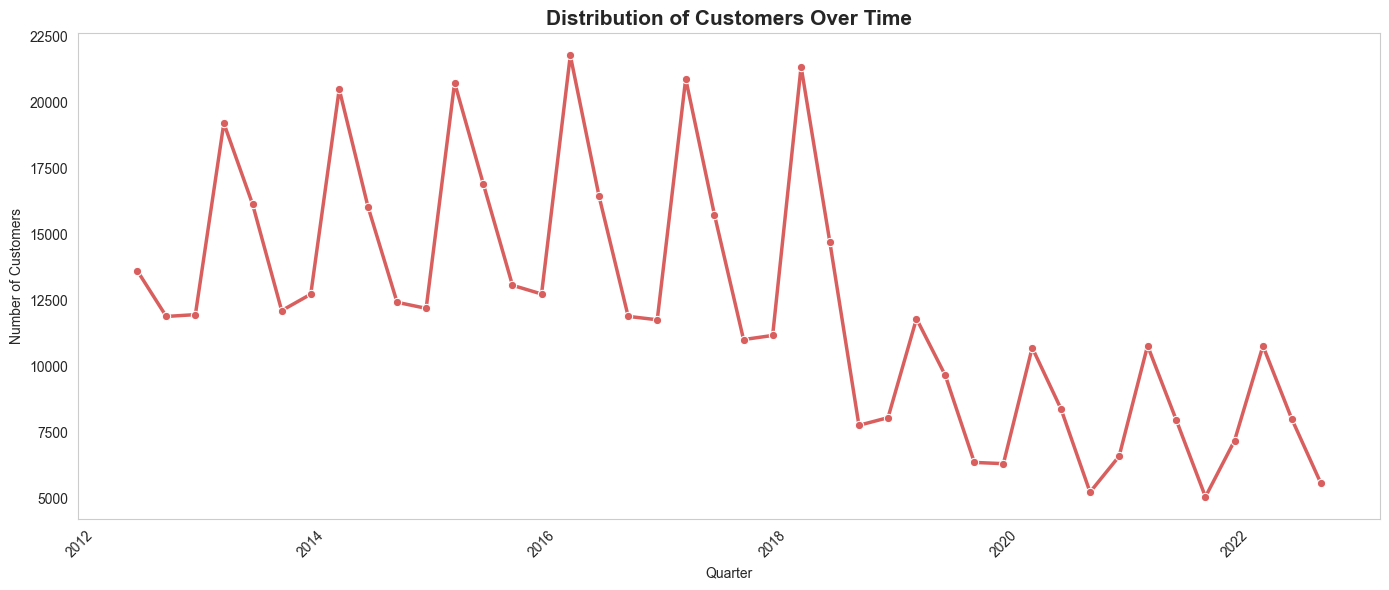

In [18]:
# ── Plot: Unique customers per quarter ───────────────────────
customer_over_time = (
    orders.assign(quarter=orders["order_date"].dt.to_period("Q").dt.to_timestamp())
    .groupby("quarter", as_index=False)
    .agg(unique_customers=("customer_id","nunique"))
)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=customer_over_time, x="quarter", y="unique_customers",
             marker="o", linewidth=2.5, color="#D95F5F", ax=ax)
ax.grid(False)
ax.set_title("Distribution of Customers Over Time", fontsize=15, weight="bold")
ax.set_xlabel("Quarter"); ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("data/output/customer_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.2 RFM Segmentation

The RFM scores translate raw transactional data into a standardized 1–5 scale (5 = best).

| Dimension | Metric | Insight |
|---|---|---|
| **Recency (R)** | Days since last purchase | Best predictor of response to new offers |
| **Frequency (F)** | Total unique orders | Measures shopping habit & engagement |
| **Monetary (M)** | Total revenue from customer | Identifies high-value "heavy lifters" |


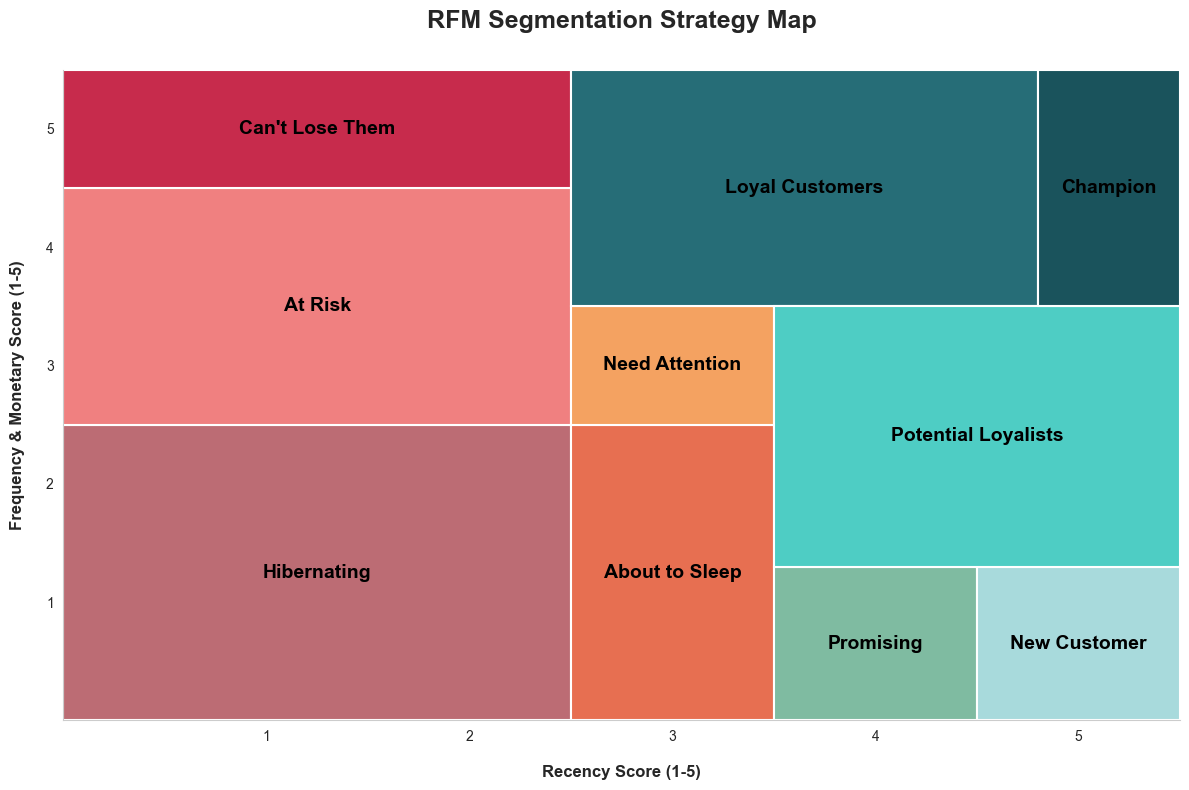

In [19]:
# ── RFM Strategy Map ─────────────────────────────────────────
SEGMENTS_MAP = [
    {"label": "Hibernating",    "coords": [0, 2.5, 0, 2.5],   "color": RFM_COLORS["Hibernating"]},
    {"label": "At Risk",        "coords": [0, 2.5, 2.5, 4.5], "color": RFM_COLORS["At Risk"]},
    {"label": "Can't Lose Them","coords": [0, 2.5, 4.5, 5.5], "color": RFM_COLORS["Can't Lose Them"]},
    {"label": "About to Sleep", "coords": [2.5, 3.5, 0, 2.5], "color": RFM_COLORS["About to Sleep"]},
    {"label": "Need Attention", "coords": [2.5, 3.5, 2.5, 3.5],"color": RFM_COLORS["Need Attention"]},
    {"label": "Loyal Customers","coords": [2.5, 4.8, 3.5, 5.5],"color": RFM_COLORS["Loyal Customers"]},
    {"label": "Promising",      "coords": [3.5, 4.5, 0, 1.3], "color": RFM_COLORS["Promising"]},
    {"label": "New Customer",   "coords": [4.5, 5.5, 0, 1.3], "color": RFM_COLORS["New Customer"]},
    {"label": "Potential Loyalists","coords":[3.5, 5.5, 1.3, 3.5],"color":RFM_COLORS["Potential Loyalists"]},
    {"label": "Champion",       "coords": [4.8, 5.5, 3.5, 5.5],"color": RFM_COLORS["Champion"]},
]

fig, ax = plt.subplots(figsize=(12, 8))
for seg in SEGMENTS_MAP:
    x0, x1, y0, y1 = seg["coords"]
    ax.add_patch(patches.Rectangle(
        (x0, y0), x1-x0, y1-y0, linewidth=1.5, edgecolor="white", facecolor=seg["color"]
    ))
    ax.text((x0+x1)/2, (y0+y1)/2, seg["label"],
            color="black", weight="bold", ha="center", va="center", fontsize=14)

ax.set_xlim(0, 5.5); ax.set_ylim(0, 5.5)
ax.set_xticks([1,2,3,4,5]); ax.set_yticks([1,2,3,4,5])
ax.set_xlabel("Recency Score (1-5)", fontsize=12, fontweight="bold", labelpad=15)
ax.set_ylabel("Frequency & Monetary Score (1-5)", fontsize=12, fontweight="bold", labelpad=15)
ax.set_title("RFM Segmentation Strategy Map", fontsize=18, fontweight="bold", pad=30)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("data/output/rfm_strategy_map.png", dpi=150, bbox_inches="tight")
plt.show()


**Strategic Zones:**
- **Core** (top-right): Champions & Loyal Customers → reward & retain.
- **Pipeline** (bottom-right): New Customers & Promising → drive repeat purchase.
- **Danger Zone** (top-left): Can't Lose Them & At Risk → urgent reactivation.
- **Cold Zone** (bottom-left): Hibernating → lowest priority, lowest engagement.


### 3.3 RFM Scoring & Classification

In [20]:
# ── Compute RFM scores ───────────────────────────────────────
latest_date = df["order_date"].max() + dt.timedelta(days=1)
rfm_raw = df.groupby("customer_id").agg(
    Recency=("order_date",  lambda x: (latest_date - x.max()).days),
    Frequency=("order_id",  "count"),
    Monetary=("revenue",    "sum")
)

rfm_raw["R_Score"]  = pd.qcut(rfm_raw["Recency"].rank(method="first"),   5, labels=[5,4,3,2,1])
rfm_raw["F_Score"]  = pd.qcut(rfm_raw["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm_raw["M_Score"]  = pd.qcut(rfm_raw["Monetary"].rank(method="first"),  5, labels=[1,2,3,4,5])
rfm_raw["FM_Score"] = (rfm_raw["F_Score"].astype(int) + rfm_raw["M_Score"].astype(int)) / 2

def classify_segment(row):
    r, fm = float(row["R_Score"]), float(row["FM_Score"])
    if   r <= 2.5: return "Hibernating" if fm <= 2.5 else ("At Risk" if fm <= 4.5 else "Can't Lose Them")
    elif r <= 3.5: return "About to Sleep" if fm <= 2.5 else ("Need Attention" if fm <= 3.5 else "Loyal Customers")
    elif r <= 4.5: return "Promising" if fm <= 1.3 else ("Potential Loyalists" if fm <= 3.5 else "Loyal Customers")
    else:          return "New Customer" if fm <= 1.3 else ("Potential Loyalists" if fm <= 3.5 else
                          ("Champion" if r >= 4.8 else "Loyal Customers"))

rfm_raw["Segment"] = rfm_raw.apply(classify_segment, axis=1)
print("Classification complete.")
rfm_raw[["R_Score","F_Score","M_Score","FM_Score","Segment"]].head()


Classification complete.


,R_Score,F_Score,M_Score,FM_Score,Segment
customer_id,,,,,
1,4,4,3,3.5,Potential Loyalists
2,5,3,4,3.5,Potential Loyalists
3,1,2,2,2.0,Hibernating
4,3,1,1,1.0,About to Sleep
5,3,3,3,3.0,Need Attention


### 3.4 Segment Distribution (Treemap)

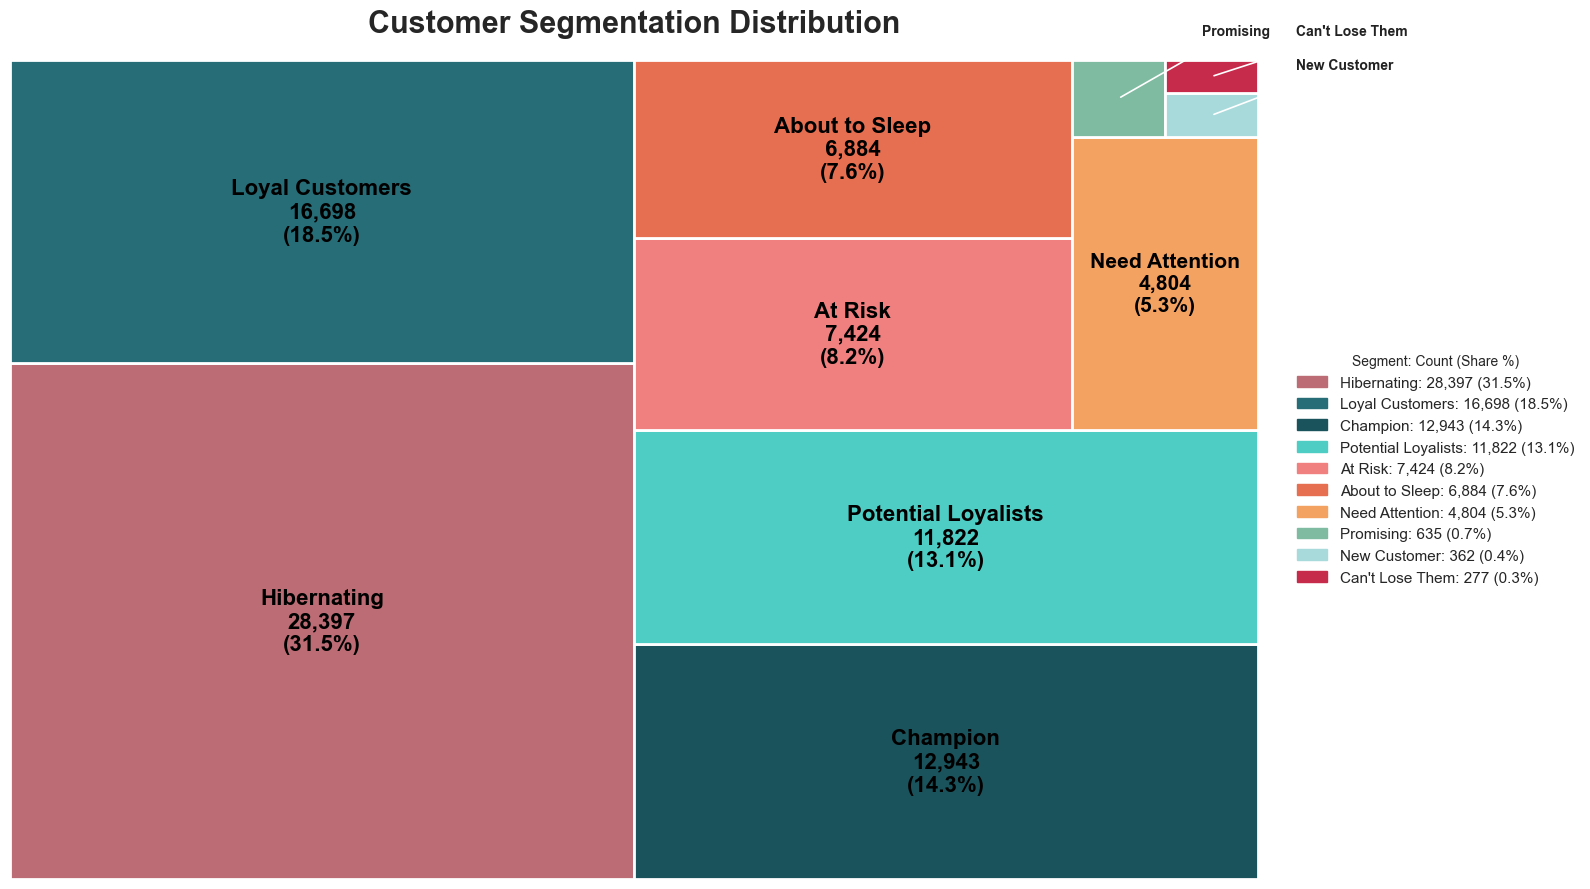

In [21]:
# ── Treemap of customer segment counts ───────────────────────
segment_counts = rfm_raw["Segment"].value_counts().reset_index()
segment_counts.columns = ["Segment", "Count"]
total_customers = segment_counts["Count"].sum()
colors = [RFM_COLORS.get(s, "#DDD") for s in segment_counts["Segment"]]

fig, ax = plt.subplots(figsize=(16, 9), facecolor="white")
ax.set_facecolor("white")
rects = squarify.squarify(squarify.normalize_sizes(segment_counts["Count"], 100, 100), 0, 0, 100, 100)

for i, rect in enumerate(rects):
    x, y, dx, dy = rect["x"], rect["y"], rect["dx"], rect["dy"]
    seg = segment_counts.loc[i, "Segment"]
    cnt = segment_counts.loc[i, "Count"]
    pct = cnt / total_customers
    ax.bar(x, dy, width=dx, bottom=y, align="edge",
           color=colors[i], edgecolor="white", linewidth=2)
    area = dx * dy
    if area > 250:
        ax.text(x+dx/2, y+dy/2, f"{seg}\n{cnt:,}\n({pct:.1%})",
                ha="center", va="center", fontsize=min(max(area/35,9),16),
                color="black", weight="bold")
    elif area > 80:
        ax.text(x+dx/2, y+dy/2, seg, ha="center", va="center",
                fontsize=9, color="white", weight="bold")
    else:
        ax.annotate(seg, xy=(x+dx/2, y+dy/2), xytext=(x+dx+3, y+dy+3),
                    fontsize=10, fontweight="bold", color="#222",
                    arrowprops=dict(arrowstyle="-", lw=1.2))

ax.set_xlim(0,100); ax.set_ylim(0,100); ax.axis("off")
plt.title("Customer Segmentation Distribution", fontsize=22, weight="bold", pad=20)
plt.legend(
    handles=[mpatches.Patch(color=RFM_COLORS[r["Segment"]],
             label=f"{r['Segment']}: {r['Count']:,} ({r['Count']/total_customers:.1%})")
             for _, r in segment_counts.iterrows()],
    title="Segment: Count (Share %)", loc="center left",
    bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=11)
plt.tight_layout()
plt.savefig("data/output/distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.5 Segment Volume vs Average Spend

/var/folders/jq/3spgz0t105z044g721j_zwdw0000gn/T/ipykernel_19618/145774150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="Count",     y="Segment", palette=RFM_COLORS, ax=ax1)
/var/folders/jq/3spgz0t105z044g721j_zwdw0000gn/T/ipykernel_19618/145774150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x="Avg_Value", y="Segment", palette=RFM_COLORS, ax=ax2)


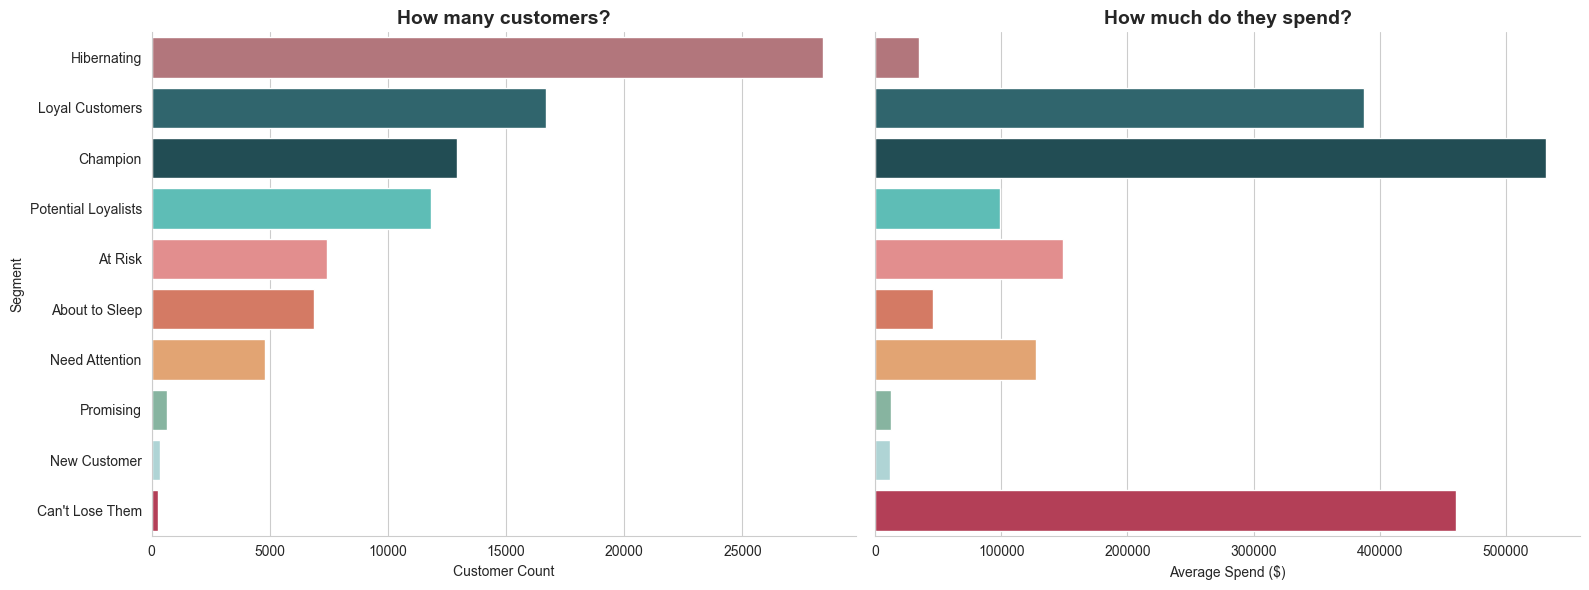

In [22]:
df_plot = (
    rfm_raw.groupby("Segment")
    .agg(Count=("Recency","count"), Avg_Value=("Monetary","mean"))
    .reset_index()
    .sort_values("Count", ascending=False)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_plot, x="Count",     y="Segment", palette=RFM_COLORS, ax=ax1)
sns.barplot(data=df_plot, x="Avg_Value", y="Segment", palette=RFM_COLORS, ax=ax2)
ax1.set_title("How many customers?",    fontweight="bold", fontsize=14)
ax1.set_xlabel("Customer Count")
ax2.set_title("How much do they spend?",fontweight="bold", fontsize=14)
ax2.set_xlabel("Average Spend ($)")
ax2.set_yticklabels([]); ax2.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()


### 3.6 Customer Lifetime Value (CLV)

CLV predicts total future net profit from a customer. It has three pillars:
- **AOV** (Average Order Value): spending per transaction
- **Purchase Frequency**: orders per year
- **Customer Lifespan**: expected active years before churn


In [23]:
# ── CLV calculation ──────────────────────────────────────────
PROFIT_MARGIN     = 0.10   # 10%
PREDICTED_LIFESPAN = 3     # years

rfm_raw["AOV"]            = rfm_raw["Monetary"] / rfm_raw["Frequency"]
rfm_raw["Yearly_Revenue"] = rfm_raw["Monetary"]
rfm_raw["CLV"]            = rfm_raw["Yearly_Revenue"] * PROFIT_MARGIN * PREDICTED_LIFESPAN

clv_summary = (
    rfm_raw.groupby("Segment")["CLV"]
    .mean().sort_values(ascending=False).reset_index()
)
print("Average Predicted 3-Year CLV per Segment:")
print(clv_summary.to_string(index=False))


Average Predicted 3-Year CLV per Segment:
            Segment           CLV
           Champion 159665.747072
    Can't Lose Them 138220.300934
    Loyal Customers 116168.624964
            At Risk  44781.296369
     Need Attention  38361.736759
Potential Loyalists  29726.201208
     About to Sleep  13742.720686
        Hibernating  10458.545801
          Promising   3819.497377
       New Customer   3628.263558


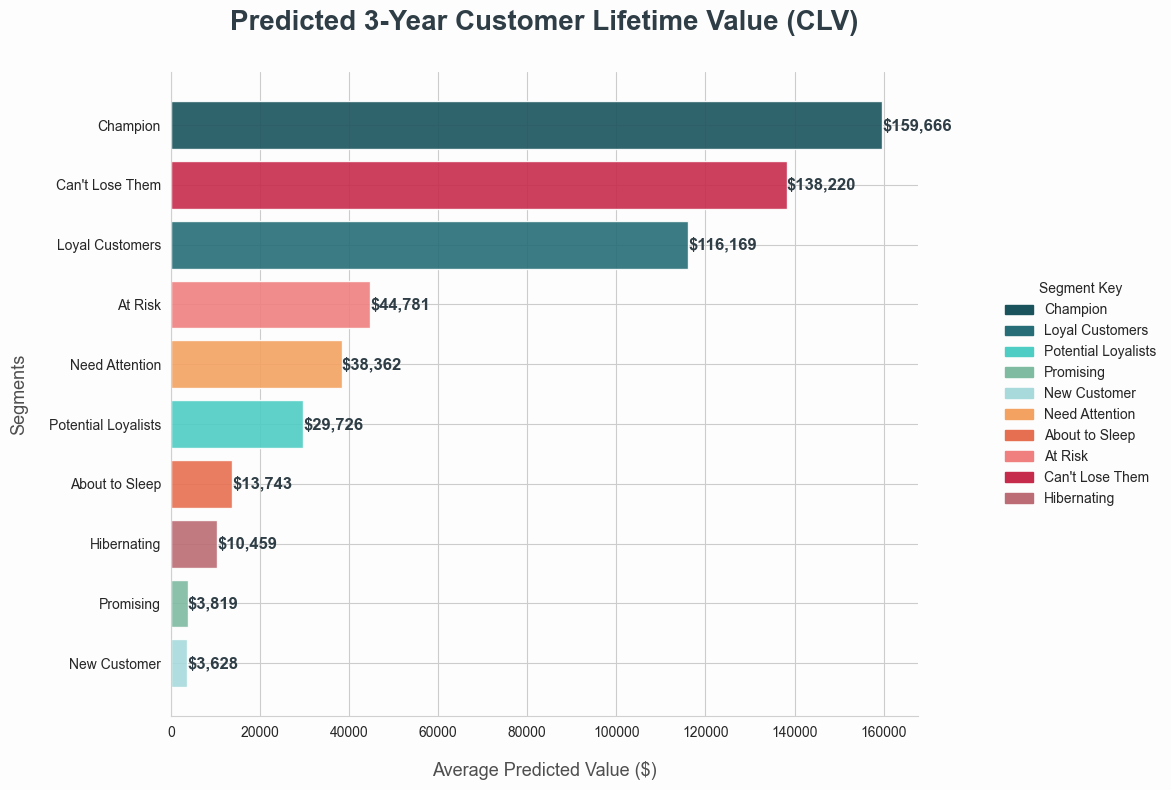

In [24]:
# ── Plot: CLV horizontal bar ─────────────────────────────────
clv_viz = rfm_raw.groupby("Segment")["CLV"].mean().sort_values(ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(12, 8), facecolor="#FDFDFD")
ax.set_facecolor("#FDFDFD")
bars = ax.barh(clv_viz["Segment"], clv_viz["CLV"],
               color=[RFM_COLORS.get(s,"#DDD") for s in clv_viz["Segment"]], alpha=0.9)

for bar in bars:
    w = bar.get_width()
    ax.text(w+10, bar.get_y()+bar.get_height()/2,
            f"${w:,.0f}", va="center", fontweight="bold", color="#2F3E46", fontsize=12)

ax.set_title("Predicted 3-Year Customer Lifetime Value (CLV)",
             fontsize=20, fontweight="bold", pad=30, color="#2F3E46")
ax.set_xlabel("Average Predicted Value ($)", fontsize=13, color="#4F4F4F", labelpad=15)
ax.set_ylabel("Segments", fontsize=13, color="#4F4F4F", labelpad=15)
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#D0D0D0")
ax.legend(handles=[mpatches.Patch(color=RFM_COLORS[s], label=s) for s in RFM_COLORS],
          title="Segment Key", loc="center left", bbox_to_anchor=(1.1, 0.5), frameon=False)
plt.tight_layout()
plt.savefig("data/output/clv.png", dpi=150, bbox_inches="tight")
plt.show()
